In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Step 1: Load Dataset
df = pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
data = df["Age"].dropna()

In [8]:
print("Mean:", data.mean())
print("Median:", data.median())
print("Mode:")
print(data.mode())

Mean: 29.69911764705882
Median: 28.0
Mode:
0    24.0
Name: Age, dtype: float64


In [11]:
variance = data.var()
std_dev = data.std()

Q1 = data.quantile(0.25)
Q2 = data.quantile(0.50)
Q3 = data.quantile(0.75)

IQR = Q3 - Q1

print("Variance:", variance)
print("Standard Deviation:", std_dev)

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)

print("IQR:", IQR)

Variance: 211.0191247463081
Standard Deviation: 14.526497332334044
Q1: 20.125
Q2: 28.0
Q3: 38.0
IQR: 17.875


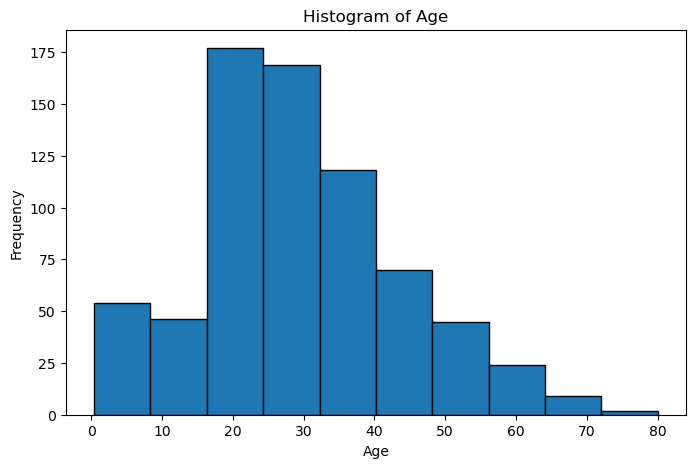

In [12]:
plt.figure(figsize=(8,5))
plt.hist(data, bins=10, edgecolor="black")

plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

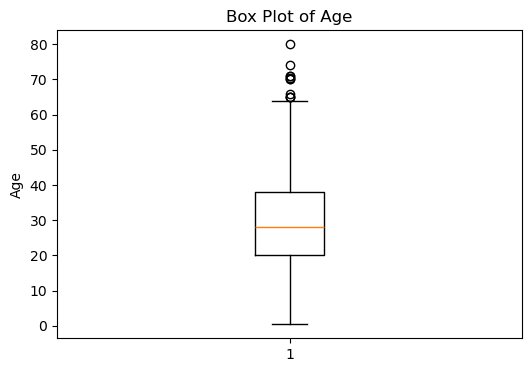

In [13]:
plt.figure(figsize=(6,4))
plt.boxplot(data)

plt.title("Box Plot of Age")
plt.ylabel("Age")

plt.show()

In [14]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = data[(data < lower_limit) | (data > upper_limit)]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Outliers:")
print(outliers)

print("Number of Outliers:", len(outliers))

Lower Limit: -6.6875
Upper Limit: 64.8125
Outliers:
33     66.0
54     65.0
96     71.0
116    70.5
280    65.0
456    65.0
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64
Number of Outliers: 11


In [15]:
clean_df = df[(df["Age"] >= lower_limit) & (df["Age"] <= upper_limit)]

In [16]:
print("Rows Before Cleaning:", len(df))

Rows Before Cleaning: 891


In [17]:
print("Rows After Cleaning:", len(clean_df))

Rows After Cleaning: 703


In [18]:
clean_data = clean_df["Age"]

In [19]:
print("Mean:", clean_data.mean())
print("Median:", clean_data.median())
print("Mode:")
print(clean_data.mode())

print("Variance:", clean_data.var())
print("Standard Deviation:", clean_data.std())

print("Q1:", clean_data.quantile(0.25))
print("Q2:", clean_data.quantile(0.50))
print("Q3:", clean_data.quantile(0.75))
print("IQR:", clean_data.quantile(0.75) - clean_data.quantile(0.25))

Mean: 29.07207681365576
Median: 28.0
Mode:
0    24.0
Name: Age, dtype: float64
Variance: 188.4711002391054
Standard Deviation: 13.72847771018715
Q1: 20.0
Q2: 28.0
Q3: 38.0
IQR: 18.0


In [20]:
clean_df.to_csv("cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
